In [1]:
import numpy as np
import healpy as hp

import matplotlib
from matplotlib import pyplot as plt

from scipy import stats
import matplotlib.gridspec as gridspec
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from matplotlib import cm
from scipy.optimize import minimize
from astropy.cosmology import Planck18
from dynesty import NestedSampler
from dynesty import plotting as dyplot
from dynesty import utils as dyfunc
from astropy.coordinates import SkyCoord
from healpy.newvisufunc import projview

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Define parameters

In [3]:
G_hi = 20.5

In [4]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.6])
z_array = range(len(z_bins)-1)
mask = 0.5

## Limit scales to $30\geq s \geq 80h^{-1}$ Mpc

In [5]:
# Create the bins array
rmin = 30 #-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 80 #+delta_max*offset # 200
nbins = 10 #int((rmax-rmin)/offset)
rbins_chi2 = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins_chi2, quaia.recenter(rbins_chi2), np.diff(quaia.recenter(rbins_chi2))

(array([30., 35., 40., 45., 50., 55., 60., 65., 70., 75., 80.]),
 array([32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5, 67.5, 72.5, 77.5]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [6]:
pimax = 80 # 40 # 5000.0 # 40.0\

## Pick cosmology

In [7]:
cosmo = 'Planck'

# Visualize the luminosity threshold cuts and redshift bins

In [9]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])[:0:-1]
L_bins

array([-20., -25., -26., -27.])

In [10]:
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_orange = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_green = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(L_bins)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
colors = ['Red', 'Orange', 'Green', 'Blue']

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_28511/197265515.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
/tmp/ipykernel_28511/197265515.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_28511/197265515.py:41: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('$N_\mathrm{QSO}$')
/tmp/ipykernel_28511/197265515.py:48: SyntaxWarning: invalid escape sequenc

0.6894778799840835
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.31              224099 vs 324336
0.6998052036780241
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.28              464321 vs 648196
0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked by MC but not already by selfunc: 352
G20.5_zmin3.0zmax4.6_Lmax-20.0: 0.22              28576 vs 36458
0.5740493621004301
Pixels masked by MC but not already by selfunc: 472
G20.5_zmin0.0zmax1.0_Lmax-25.0: 0.39              33897 vs 55261
0.7764060682819681
Pixels masked by MC but not already by selfunc: 2269
G20.5_zmin1.0zmax2.0_Lmax-25.0: 0.32              340084 vs 502242
0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-25.0: 0.25              214535 vs 286508
0.7686898940836221
Pixels masked 

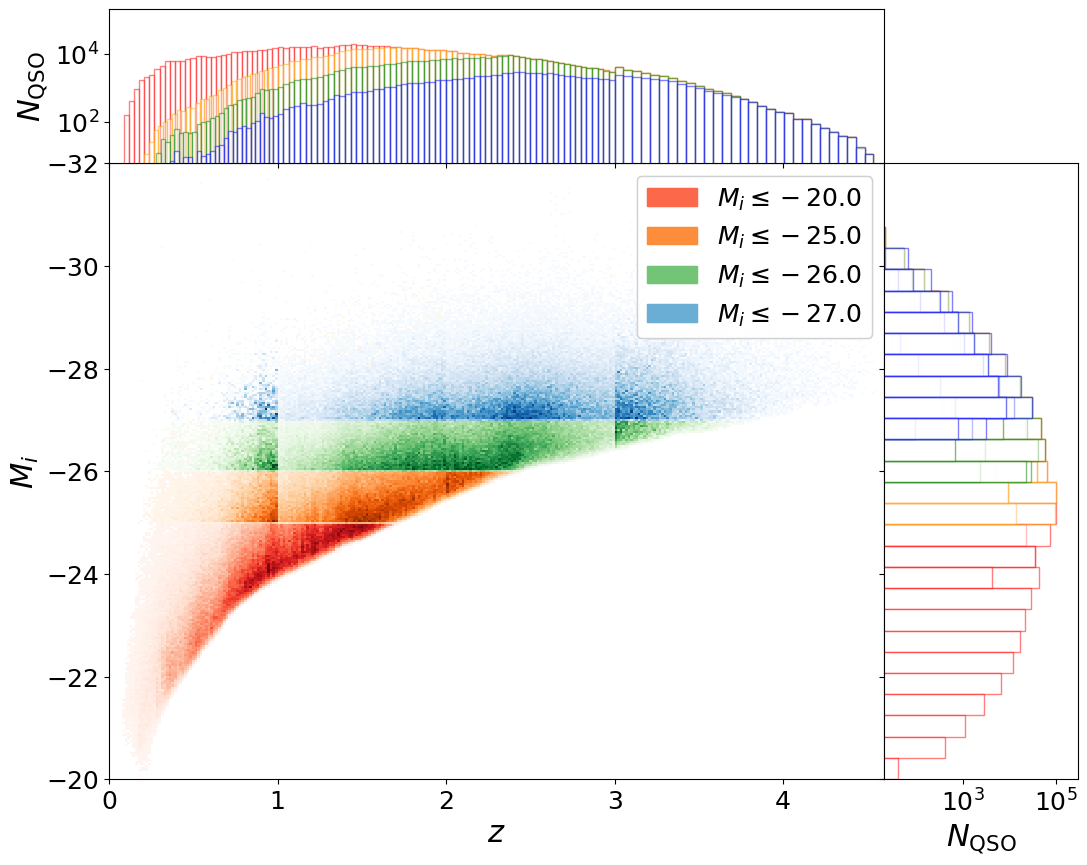

In [11]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)
fac_rand = 25

ax1 = fig.add_subplot(gs[2])
ax2 = fig.add_subplot(gs[0])
ax3 = fig.add_subplot(gs[3])

N_q = {L: [] for L in L_bins}

for i in range(len(L_bins)):
        
    for j in z_array:
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                             bins = [z_bins, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = [None, None])
        quaia.absolute(tab_datahi_mask_zbin0, G_hi)
        h1, xedges, yedges, image = ax1.hist2d(tab_datahi_mask_zbin0['redshift_quaia'], tab_datahi_mask_zbin0['M_i'],
                                               cmap = plt.get_cmap('{}s'.format(colors[i])), bins = [np.linspace(0, 4.6, 300), np.linspace(-32, -20, 300)],
                                               cmin = 1)
        xlim = ax1.get_xlim()

        ax2.hist(tab_datahi_mask_zbin0['redshift_quaia'], color = 'white', edgecolor = colors[i], bins = 30, alpha = 0.5)
        ax3.hist(tab_datahi_mask_zbin0['M_i'], color = 'white', edgecolor = colors[i], orientation = 'horizontal', bins = np.linspace(-32, -20, 30), alpha = 0.5, label = '$M_i\leq{}$'.format(L_bins[i]))
        
        N_q[L_bins[i]].append(len(tab_datahi_mask_zbin0))
    
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)

ax2.set_ylabel('$N_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3.set_xlabel('$N_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(-20, -32)
ax3.set_xlim(2e1,3e5)

custom_lines = [mpatches.Patch(color=plt.get_cmap('{}s'.format(colors[i]))(np.array(0.5))) for i in range(len(L_bins))]
second_legend = ax1.legend(custom_lines, ['$M_i\leq{}$'.format(L) for L in L_bins])
fig.add_artist(second_legend)

plt.show()

# Debug covariance
## Plot the amplitude of the diagonal of the covariance

In [12]:
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(L_bins)))

In [80]:
N = 30 #15 #45 #85

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:34: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_28511/2533997832.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[i], linestyle = linestyles[i])
/tmp/ipykernel_28511/2533997832.py:28: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_28511/2533997832.py:34: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))


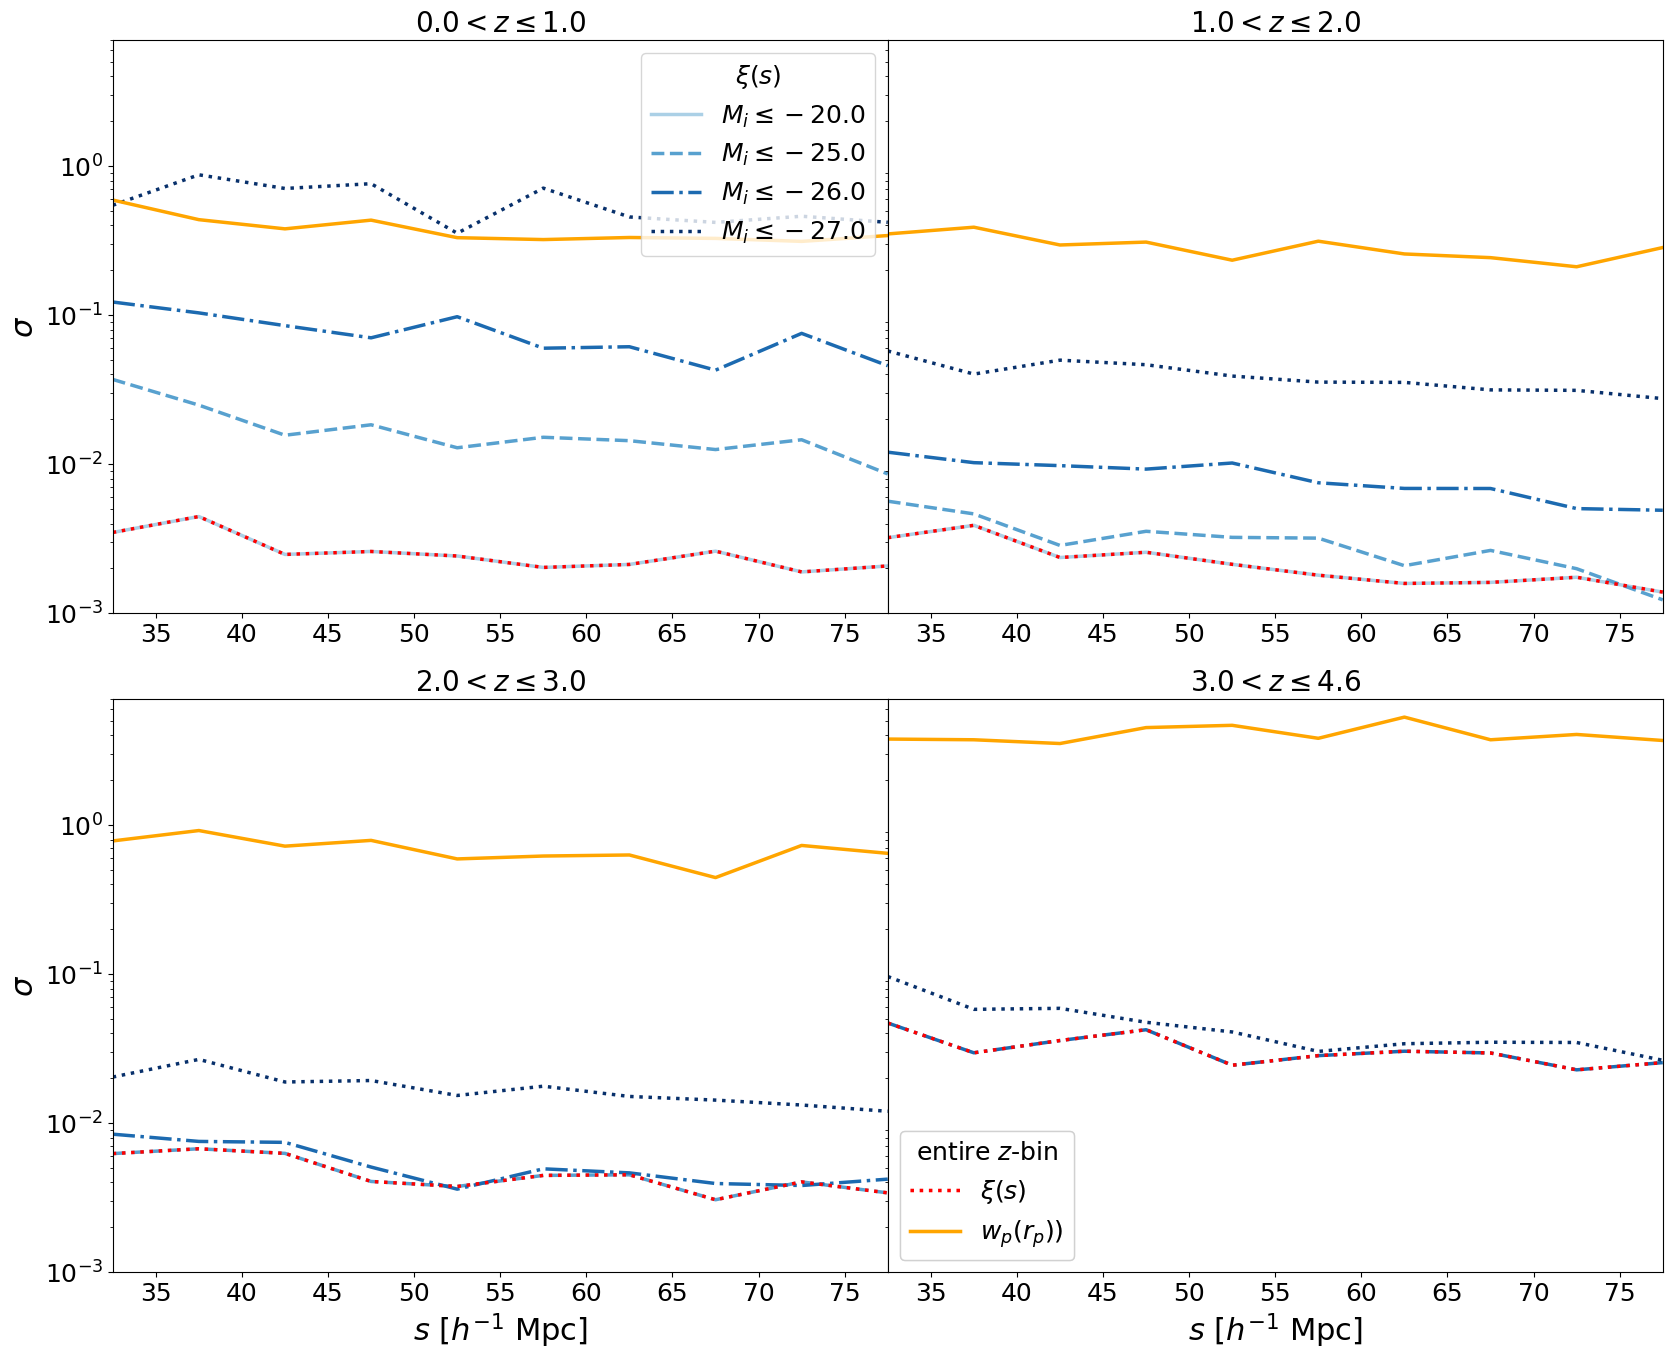

In [81]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[i], linestyle = linestyles[i])
            # print(L_bins[i], sigma)
            
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'red', linestyle = ':')#, label = r'$\xi(s)$')

    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N{}_Planck_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N)) 
    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'orange')
    
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_yscale('log')
    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
            
    if j %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    # ax1.set_ylim(1e-6, 4e1)
    ax1.set_ylim(1e-3, 7)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

    if j ==0:
        ax1.legend(title = r'$\xi(s)$', title_fontsize = 18)

custom_lines = [Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'orange', linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', r'$w_p(r_p))$',], title = 'entire $z$-bin', title_fontsize = 18)
fig.add_artist(second_legend)

plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_28511/2220350090.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[j], linestyle = linestyles[j])
/tmp/ipykernel_28511/2220350090.py:28: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_28511/2220350090.py:33: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))


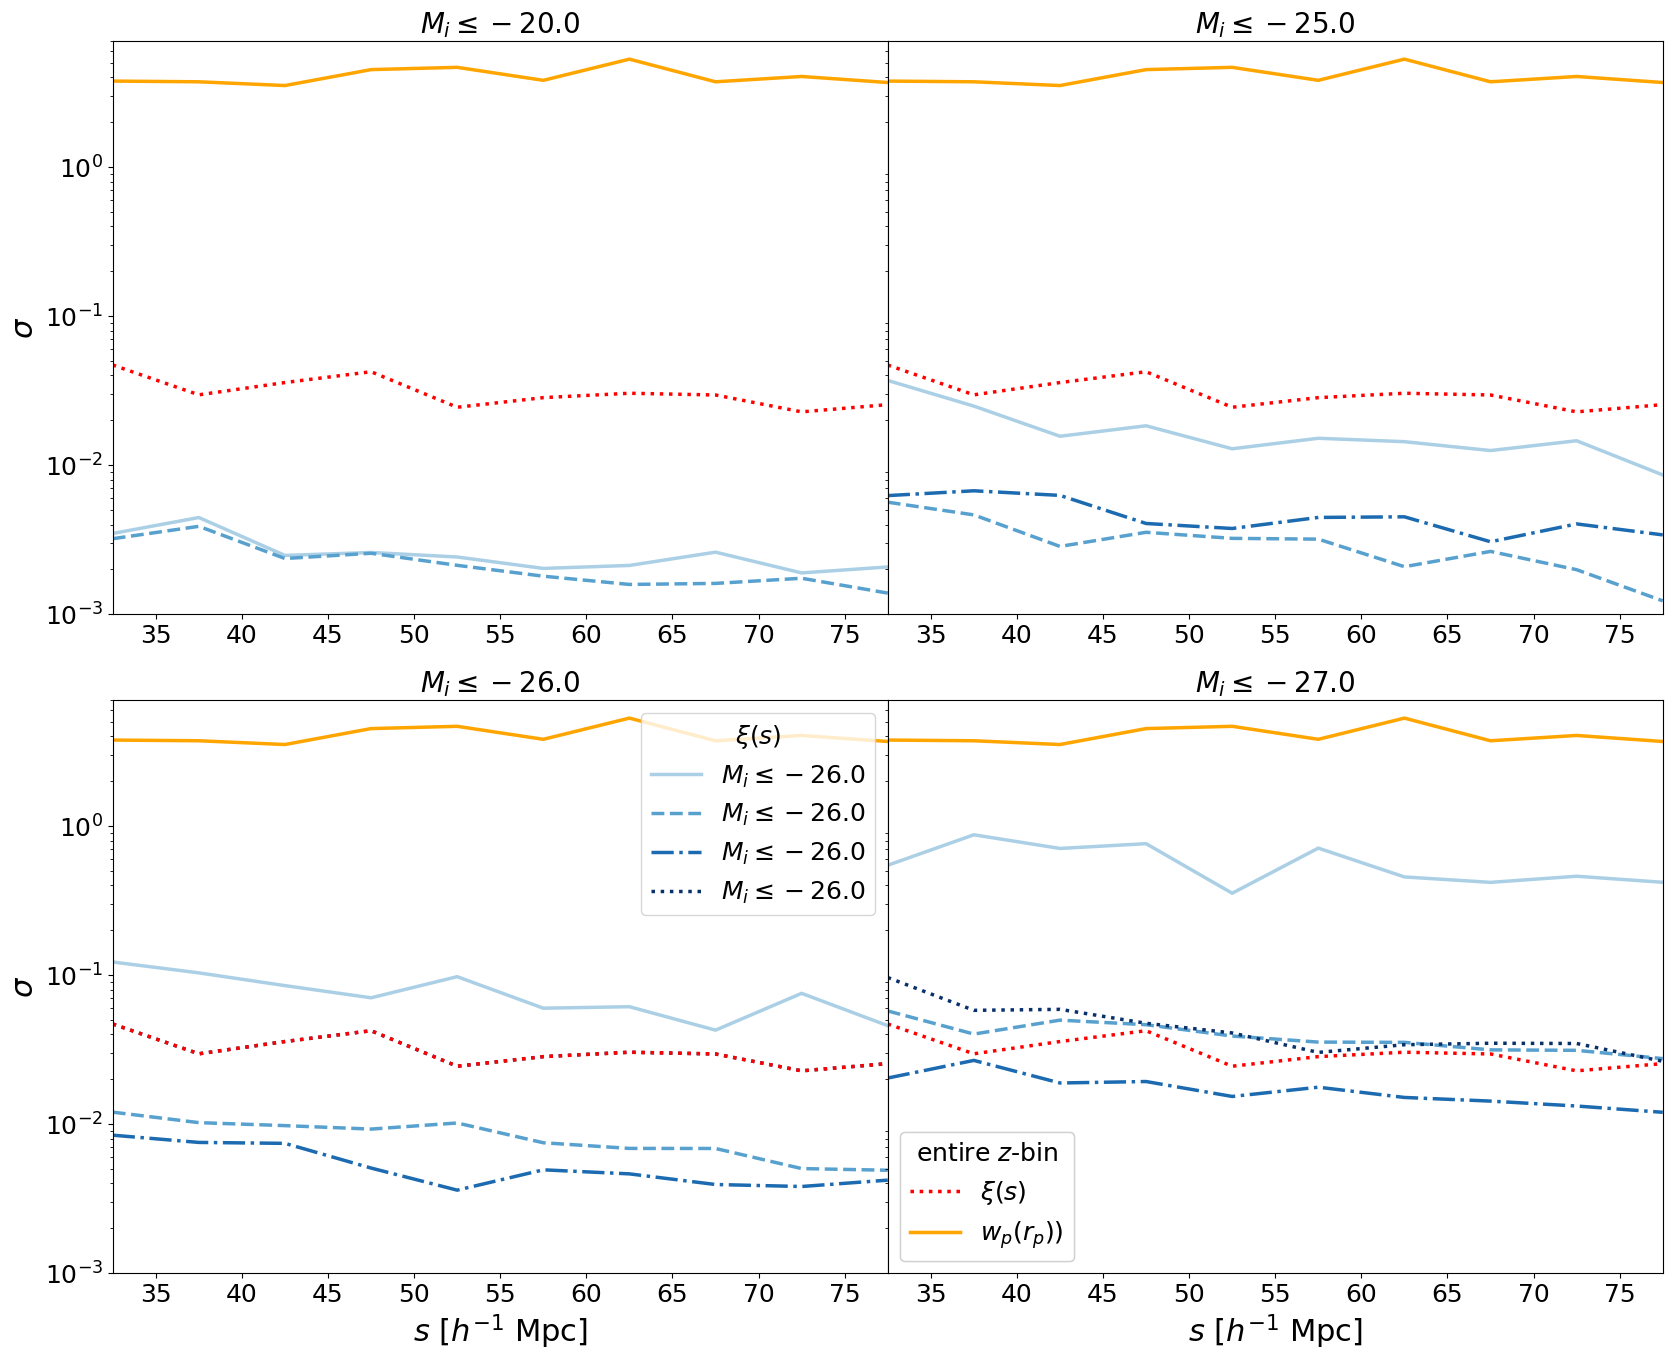

In [82]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo)))
            ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(var), linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[j], linestyle = linestyles[j])

    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'red', linestyle = ':')#, label = r'$\xi(s)$')

    C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N{}_Planck_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N)) 
    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'orange')
    
    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])
    ax1.set_yscale('log')

    if i > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
            
    if i %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-3, 7)
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    if i ==2:
        ax1.legend(title = r'$\xi(s)$', title_fontsize = 18)

custom_lines = [Line2D([0], [0], color = 'red', linestyle = ':', linewidth = 2.5), Line2D([0], [0], color = 'orange', linestyle = '-', linewidth = 2.5)]
second_legend = ax1.legend(custom_lines, [r'$\xi(s)$', r'$w_p(r_p))$',], title = 'entire $z$-bin', title_fontsize = 18)
fig.add_artist(second_legend)

plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:33: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_28511/4218845281.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(rbins_chi2), sigma, linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[i], linestyle = linestyles[i])
/tmp/ipykernel_28511/4218845281.py:28: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_28511/4218845281.py:33: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))
/tmp/ipykernel_28511/4218845281.py:15: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.diag(np.sqrt(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}

-20.0 [0.00403144 0.0043304  0.00286761 0.00236579 0.00219364 0.00175448
 0.00188024 0.00290127 0.00164944 0.00200143]
-25.0 [0.0423711  0.02066435 0.0171753  0.018278   0.01223034 0.01233855
 0.01508839 0.01058434 0.01549946 0.00894465]
-26.0 [0.1176252  0.08965766 0.09753199 0.05142348 0.07806513 0.03589545
 0.05279842 0.0360049  0.07312505 0.05515219]
-27.0 [0.56031042 0.78014877 0.66375426 0.65834962 0.28526013 0.65321551
 0.4321122  0.52807203 0.50714089 0.48559381]
-20.0 [0.00394465 0.00382117 0.00248289 0.00230151 0.00206743 0.00160436
 0.00164065 0.00188653 0.00141859 0.00106455]
-25.0 [0.00634439 0.00484796 0.00293385 0.00352253 0.00334216 0.00244309
 0.00219573 0.00319941 0.00151462 0.00137107]
-26.0 [0.01368637 0.01028668 0.00941625 0.01013019 0.01080823 0.00609711
 0.00807696 0.00716608 0.0037286  0.005171  ]
-27.0 [0.06358125 0.0382222  0.03761839 0.04804892 0.03716567 0.02928182
 0.03588977 0.03226749 0.03348691 0.03150749]
-25.0 [0.00620269 0.00713728 0.00269992 0.004510

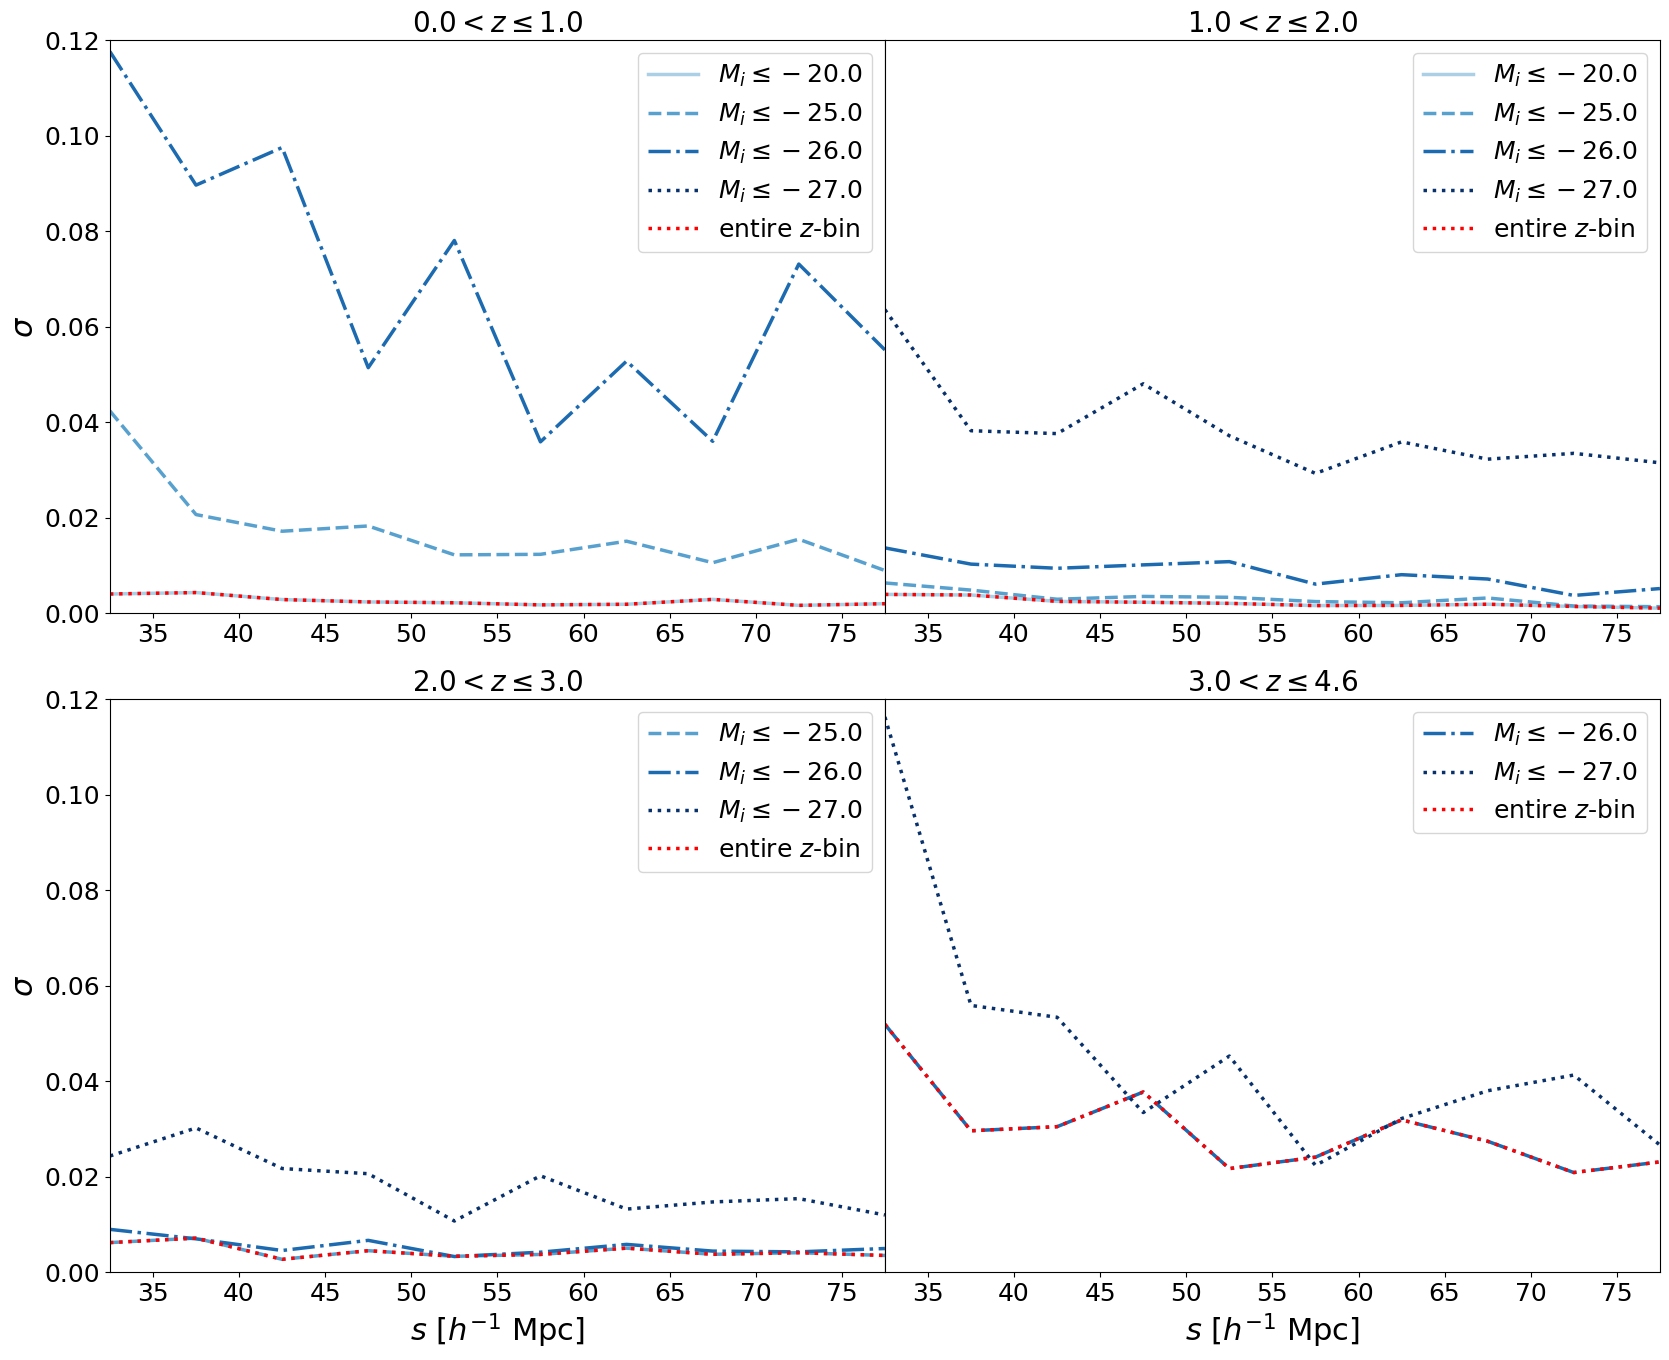

In [36]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for j in z_array:

    ax1 = fig.add_subplot(gs[j])

    # C = np.load('../results/cov_wp_G{}_rmin{}_rmax{}_nbins{}_pimax{}_zmin{:.1f}zmax{}_N{}_Planck_MC.npy'.format(G_hi, rmin, rmax, nbins, pimax, z_bins[j], z_bins[j+1], N)) 
    # ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, label = r'$w_p(r_p))$')

    for i in range(len(L_bins)):

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            sigma = np.diag(np.sqrt(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))))
            ax1.plot(quaia.recenter(rbins_chi2), sigma, linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[i], linestyle = linestyles[i])
            print(L_bins[i], sigma)
            
    C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
    ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'red', linestyle = ':', label = 'entire $z$-bin')

    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
            
    if j %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(0, 0.12)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]))

    ax1.legend()
        
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_28511/3425796977.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(quaia.recenter(rbins_chi2), sigma, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), color = cmap_blue[j], linestyle = linestyles[j])
/tmp/ipykernel_28511/3425796977.py:25: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_28511/3425796977.py:30: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))
/tmp/ipykernel_28511/3425796977.py:12: RuntimeWarning: invalid value encountered in sqrt
  sigma = np.diag(np.sqrt(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}

-20.0 [0.00403144 0.0043304  0.00286761 0.00236579 0.00219364 0.00175448
 0.00188024 0.00290127 0.00164944 0.00200143]
-20.0 [0.00394465 0.00382117 0.00248289 0.00230151 0.00206743 0.00160436
 0.00164065 0.00188653 0.00141859 0.00106455]
-25.0 [0.0423711  0.02066435 0.0171753  0.018278   0.01223034 0.01233855
 0.01508839 0.01058434 0.01549946 0.00894465]
-25.0 [0.00634439 0.00484796 0.00293385 0.00352253 0.00334216 0.00244309
 0.00219573 0.00319941 0.00151462 0.00137107]
-25.0 [0.00620269 0.00713728 0.00269992 0.0045108  0.00333626 0.00372407
 0.00504029 0.00375039 0.0040868  0.00350904]
-26.0 [0.1176252  0.08965766 0.09753199 0.05142348 0.07806513 0.03589545
 0.05279842 0.0360049  0.07312505 0.05515219]
-26.0 [0.01368637 0.01028668 0.00941625 0.01013019 0.01080823 0.00609711
 0.00807696 0.00716608 0.0037286  0.005171  ]
-26.0 [0.00897536 0.00699214 0.00455063 0.006672   0.00328455 0.00419438
 0.00582806 0.0044229  0.00426245 0.00496485]
-26.0 [0.0519216  0.02961981 0.0304806  0.037739

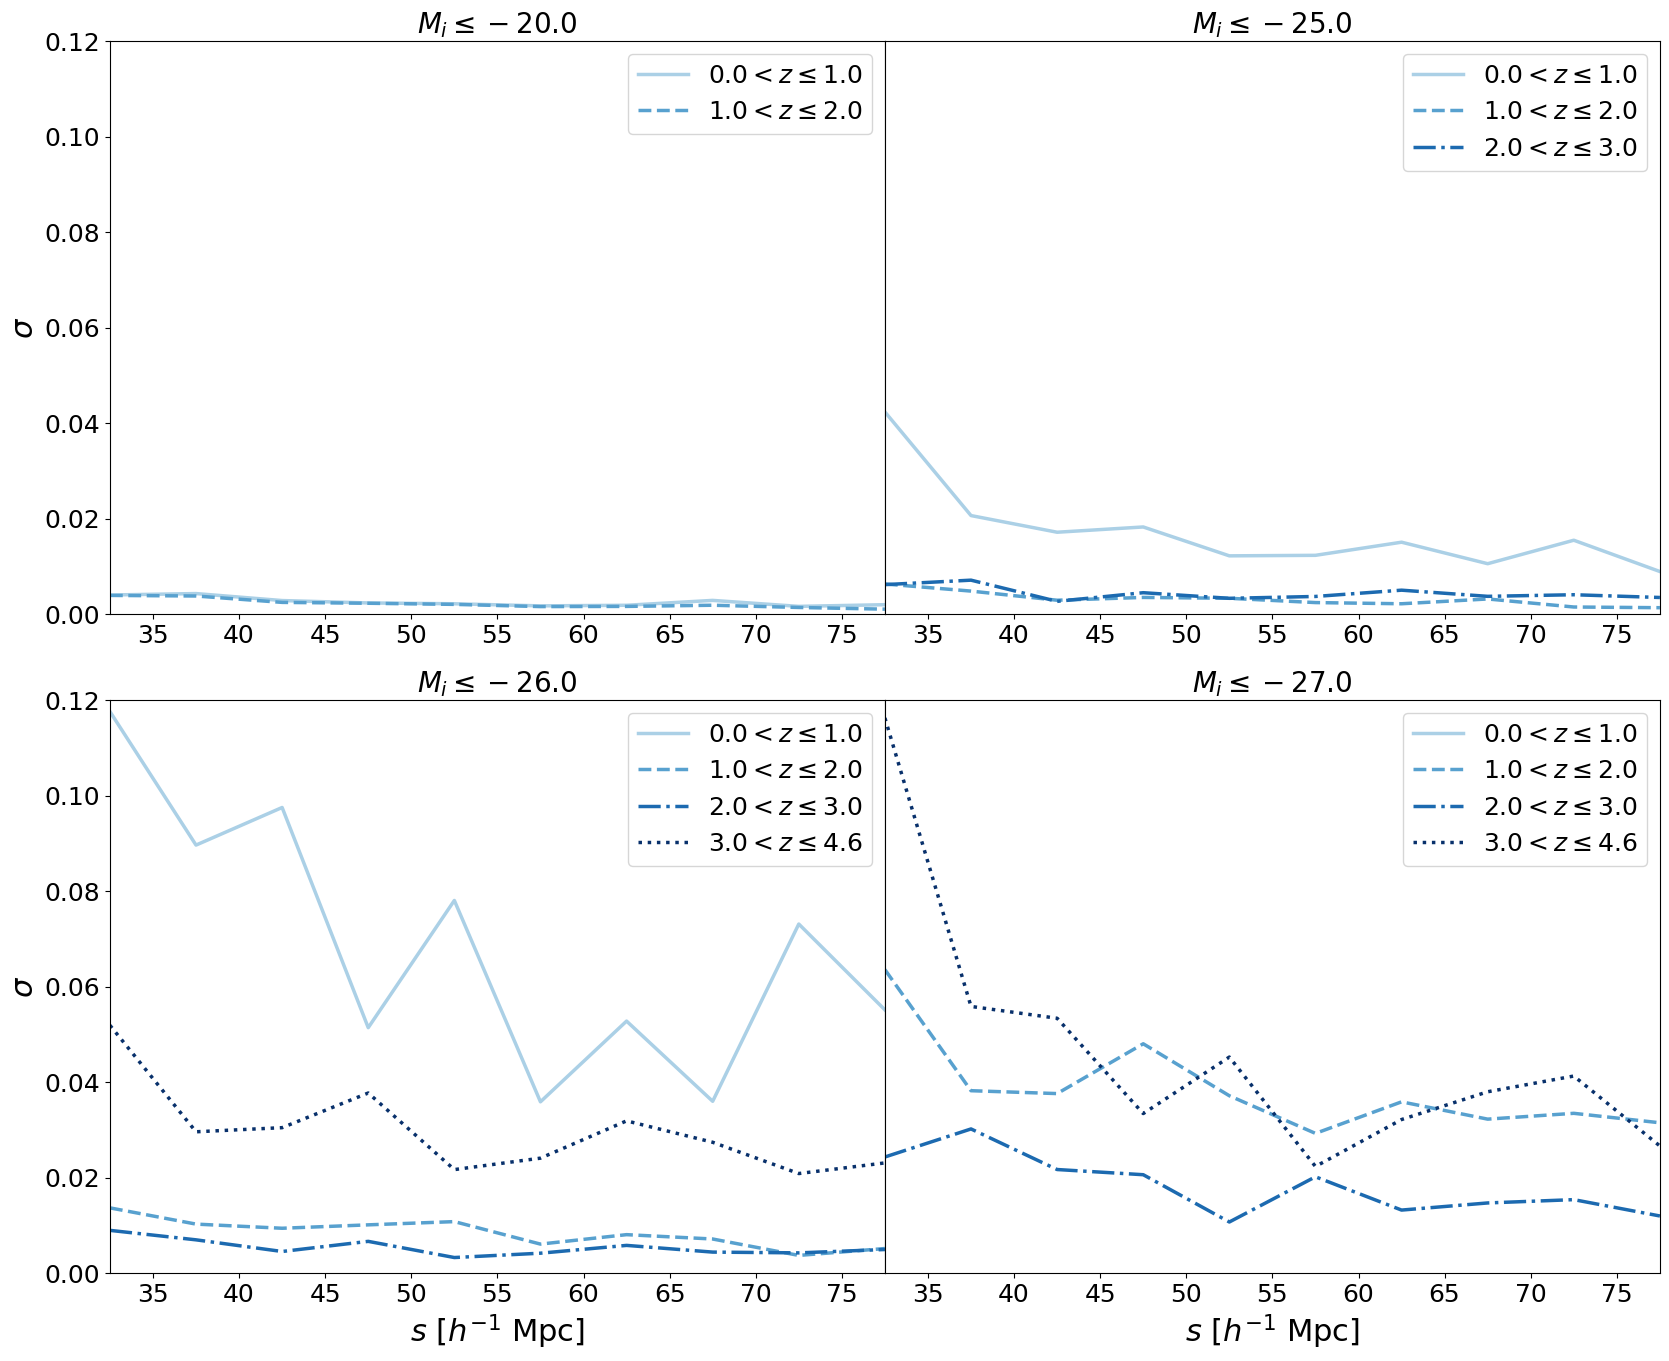

In [37]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in z_array:

        if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

            sigma = np.diag(np.sqrt(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], L_bins[i], N, cosmo))))
            ax1.plot(quaia.recenter(rbins_chi2), sigma, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(z_bins[j], z_bins[j+1]), color = cmap_blue[j], linestyle = linestyles[j])
            print(L_bins[i], sigma)
            
        # C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{:.1f}zmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, z_bins[j], z_bins[j+1], N, cosmo)) # good
        # ax1.plot(quaia.recenter(rbins_chi2), np.sqrt(np.diag(C)), linewidth = 2.5, color = 'red', linestyle = ':', label = 'entire $z$-bin')

    ax1.set_xlim(quaia.recenter(rbins_chi2)[0], quaia.recenter(rbins_chi2)[-1])

    if i > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
            
    if i %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(0, 0.12)
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    ax1.legend()
        
plt.show()